# Feature engineering: Telco Customer Churn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/projects/telco-customer-churn

Mounted at /content/drive
/content/drive/MyDrive/PORTFOLIO/telco-customer-churn


## 1. Load cleaned dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import joblib

df = pd.read_csv("data/processed/EDA-Telco-customer-churn.csv")

## 2. Train-test split


In [ ]:
X = df.drop(['Churn'], axis = 1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=44, stratify = y)

## 2. Encoding categorical variables


Method *encoding_cat_cols(data)* implemented below allows to automate process of encoding categorical binary variables by mapping a category in particular column to number of the category. Among modified data it also returns dictionary of mapped categories for each column in order to keep a user updated.

In [ ]:
def encoding_cat_cols(data):
    data = data.copy()
    cat_cols = data.select_dtypes(exclude=['number']).columns
    dict_encoding_cols = {}

    for col in cat_cols:
        if data[col].nunique() <= 2:
            categories = np.sort(data[col].unique())
            dict_encoding_cat = {cat: i for i, cat in enumerate(categories)}
            dict_encoding_cols[col] = dict_encoding_cat
            data[col] = data[col].map(dict_encoding_cat)

    return data, dict_encoding_cols

In [ ]:
y_train = y_train.map({'No': 0, 'Yes': 1})
y_test = y_test.map({'No': 0, 'Yes': 1})

In [ ]:
X_train, dict_encoding_cols = encoding_cat_cols(X_train)

In [ ]:
for col, mapping in dict_encoding_cols.items():
    X_test[col] = X_test[col].map(mapping).fillna(-1)

In [ ]:
dict_encoding_cols


{'gender': {'Female': 0, 'Male': 1},
 'SeniorCitizen': {'No': 0, 'Yes': 1},
 'Partner': {'No': 0, 'Yes': 1},
 'Dependents': {'No': 0, 'Yes': 1},
 'PhoneService': {'No': 0, 'Yes': 1},
 'PaperlessBilling': {'No': 0, 'Yes': 1}}

Binary categorical features were encoded using train-based mappings.  
The target variable was encoded separately (Yes: 1, No: 0).

## 3. New feature creation

Customers having more security/technical services are more engaged and less inclined to leave.


In [ ]:
core_services = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport'
]

X_train['ServicesCount_core'] = (X_train[core_services] == 'Yes').sum(axis=1)
X_test['ServicesCount_core'] = (X_test[core_services] == 'Yes').sum(axis=1)


In [ ]:
tmp = X_train.copy()
tmp['Churn'] = y_train


The following plots validate the predictive potential of the newly created feature.

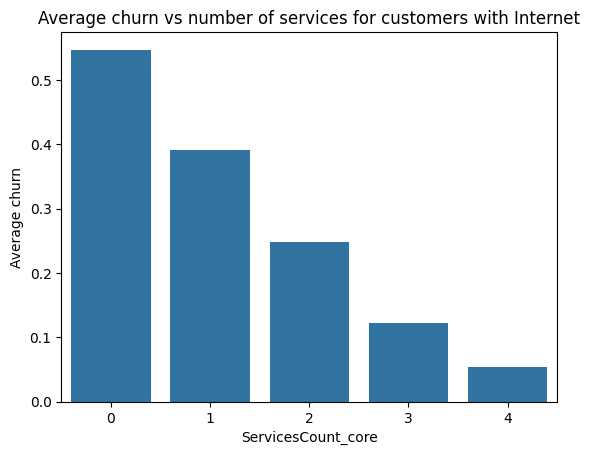

In [ ]:
sns.barplot(tmp.query('InternetService != "No"').groupby('ServicesCount_core')['Churn'].mean())
plt.ylabel('Average churn')
plt.title('Average churn vs number of services for customers with Internet')
plt.show()

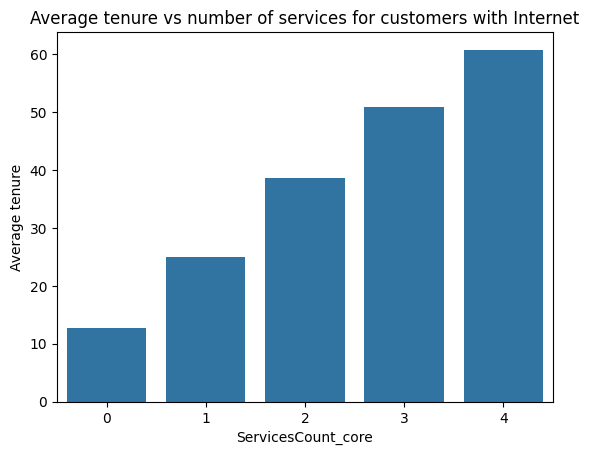

In [ ]:
sns.barplot(tmp.query('InternetService != "No"').groupby('ServicesCount_core')['tenure'].mean())
plt.ylabel('Average tenure')
plt.title('Average tenure vs number of services for customers with Internet')
plt.show()

Among customers with active internet service, churn probability decreases monotonically with the number of technical add-on services.
This suggests that service bundling significantly increases customer retention.
However, service count is strongly correlated with tenure, suggesting that long-term customers are also more likely to adopt additional services.

## 4. Feature transformations


Tenure shows a strong non-linear relationship with churn.
To allow Logistic Regression to capture this effect, tenure was discretized into quantile-based buckets using training data only.
The same bin edges were applied to the test set to prevent data leakage.

In [ ]:
tenure_bins, tenure_bin_edges = pd.qcut(X_train['tenure'], q = 6, retbins = True, duplicates = 'drop')
X_train['tenure_bucket'] = pd.cut(X_train['tenure'], bins = tenure_bin_edges, include_lowest = True)
X_test['tenure_bucket'] = pd.cut(X_test['tenure'], bins = tenure_bin_edges, include_lowest = True)


In [ ]:
joblib.dump(X_train,"data/X_train.pkl")
joblib.dump(X_test, "data/X_test.pkl")
joblib.dump(y_train, "data/y_train.pkl")
joblib.dump(y_test, "data/y_test.pkl")

['data/y_test.pkl']

## 7. Final summary

The following feature engineering steps were performed:

* Binary categorical variables were encoded using mappings learned on the training set.

* A new aggregated feature ServicesCount_core was created to capture the number of active technical add-on services.

* Tenure was discretized into quantile-based buckets (tenure_bucket) using training data only to capture non-linear effects for linear models.

Both raw and transformed features were preserved to allow different preprocessing strategies for linear and tree-based models in the modeling phase.